# **1. 라이브러리 Import**

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# 재현성을 위한 seed 설정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# **2. 데이터 준비**

### (1) 데이터 로드
### (2) 컬럼 분류
- key_cols = ['year', 'country', 'admin']
- target_col = 'infection_rate'
- climate_cols = ['max_temperature', 'min_temperature', 'avg_temperature']
- livestock_cols = ['Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']
- landuse_cols = ['rate_landuse']
### (3) X, y 분리
### (4) train, test dataset 분리
### (4) Feature scaling
- climate : standard scaling
- livestock, landuse : log transformation + standard scaling

In [2]:
# 데이터 로드
df = pd.read_csv('../data/processed/cleaned_disease_dataset_2015landuse.csv')

print(f"Total samples: {len(df):,}")
df.head()

Total samples: 473


,year,country,admin,infection_rate,max_temperature,min_temperature,avg_temperature,Buffa,Cattl,Chick,Ducks,Goats,Horse,Sheep,Swine,rate_landuse,missing_ratio
0,2010,Burkina Faso,Boucle Du Mouhoun,0.585652,307.42114,297.76172,302.50760,0.0,25.000049,164.065700,0.0,34.153420,0.693863,21.774243,9.682960,0.076206,0.0
1,2010,Burkina Faso,Cascades,0.979432,304.47192,297.88160,300.27893,0.0,38.008688,96.864817,0.0,12.506484,0.008877,12.373391,3.865450,0.074387,0.0
2,2010,Burkina Faso,Centre,1.955671,307.73170,299.50660,302.80447,0.0,17.566445,303.908919,0.0,58.134766,0.019041,40.947445,6.821150,0.407856,0.0
3,2010,Burkina Faso,Centre-est,1.037736,307.41138,298.78003,302.61942,0.0,29.597071,203.094681,0.0,69.010943,0.027864,45.871831,18.292361,0.143950,0.0
4,2010,Burkina Faso,Centre-nord,0.379147,308.31274,297.82104,303.14368,0.0,28.843678,138.295650,0.0,65.134086,0.079677,48.346972,4.834737,0.120649,0.0


In [3]:
# 컬럼 분류
key_cols = ['year', 'country', 'admin']
target_col = 'infection_rate'
climate_cols = ['max_temperature', 'min_temperature', 'avg_temperature']
livestock_cols = ['Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']
landuse_cols = ['rate_landuse']
feature_cols = climate_cols + livestock_cols + landuse_cols

print(f"Feature 컬럼 ({len(feature_cols)}개): {feature_cols}")
print(f"Target 컬럼: {target_col}")

Feature 컬럼 (12개): ['max_temperature', 'min_temperature', 'avg_temperature', 'Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine', 'rate_landuse']
Target 컬럼: infection_rate


In [4]:
# X, y 분리
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (473, 12)
y shape: (473,)


In [5]:
# train, test dataset 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("=== Random Split ===")
print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain - y 평균: {y_train.mean():.4f}, 표준편차: {y_train.std():.4f}")
print(f"Test - y 평균: {y_test.mean():.4f}, 표준편차: {y_test.std():.4f}")

=== Random Split ===
Train set: 378 samples (79.9%)
Test set: 95 samples (20.1%)

Train - y 평균: 5.5219, 표준편차: 6.7059
Test - y 평균: 5.0191, 표준편차: 6.1762


# **3. Random Forest 진행**

In [ ]:
#scaling

랜덤 포레스트 
 - 결정계수(estimator10.0000): 0.9449


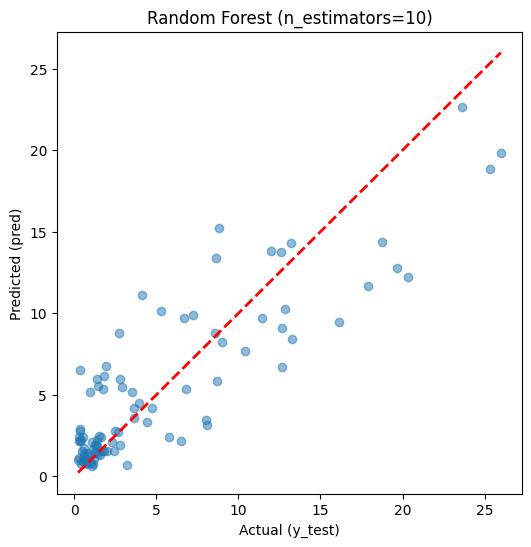

랜덤 포레스트 
 - 결정계수(estimator20.0000): 0.9554


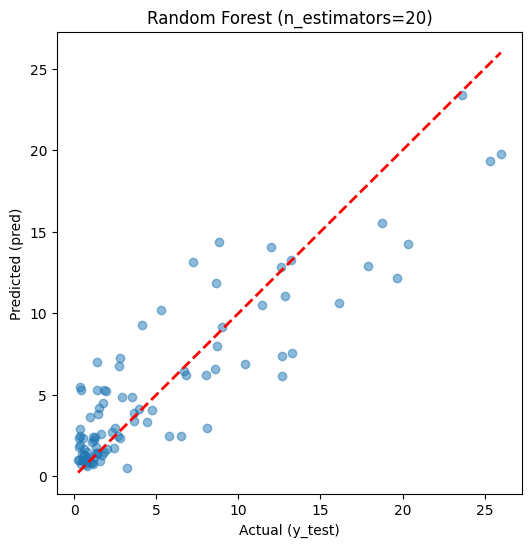

랜덤 포레스트 
 - 결정계수(estimator30.0000): 0.9625


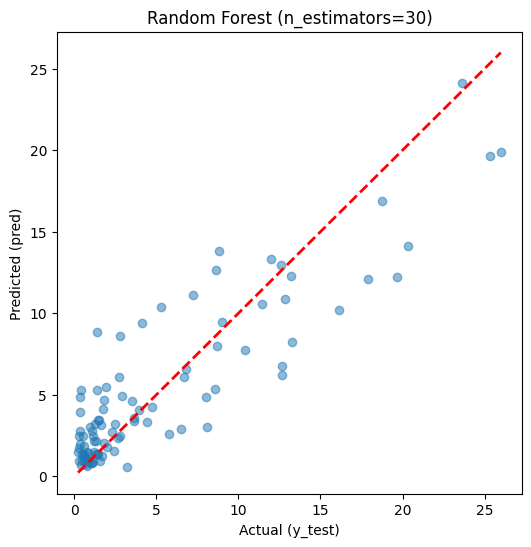

랜덤 포레스트 
 - 결정계수(estimator40.0000): 0.9625


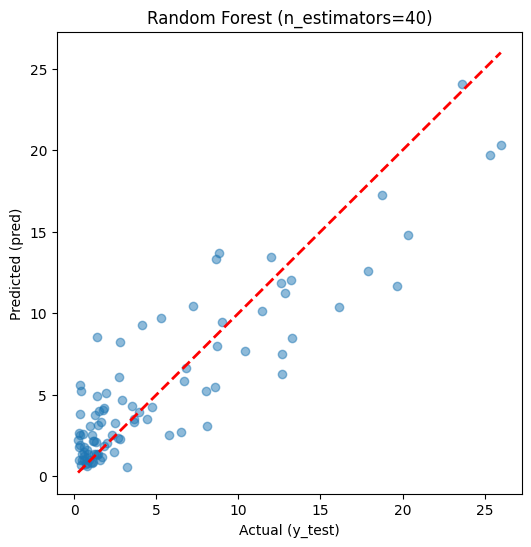

In [ ]:
#randomfrest(regression)

for i in (10,20,30,40):
    model = RandomForestRegressor(n_estimators = i, random_state= 15)
    model.fit(X_train,y_train)
    
    pred = model.predict(X_test)
    
    relation_square = model.score(X_train,y_train)
    print('랜덤 포레스트 \n - 결정계수(estimator{:.4f}): {:.4f}'.format(i,relation_square))
    
    # 기존 코드 수정
    plt.figure(figsize=(6, 6))

    # x축: 실제값(y_test), y축: 예측값(pred)
    plt.scatter(y_test, pred, alpha=0.5)

    # 기준선 그리기 (완벽하게 맞췄다면 이 선 위에 점이 있어야 함)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

    plt.xlabel('Actual (y_test)')
    plt.ylabel('Predicted (pred)')
    plt.title(f'Random Forest (n_estimators={i})')
    plt.show()

=== 랜덤 포레스트 성능 비교 (R2 Score) ===
Trees:  10 | Train R2: 0.9194 | Test R2: 0.7645
Trees:  20 | Train R2: 0.9278 | Test R2: 0.7885
Trees:  30 | Train R2: 0.9307 | Test R2: 0.7767
Trees:  40 | Train R2: 0.9319 | Test R2: 0.7841
Trees:  50 | Train R2: 0.9336 | Test R2: 0.7837
Trees: 100 | Train R2: 0.9391 | Test R2: 0.7928


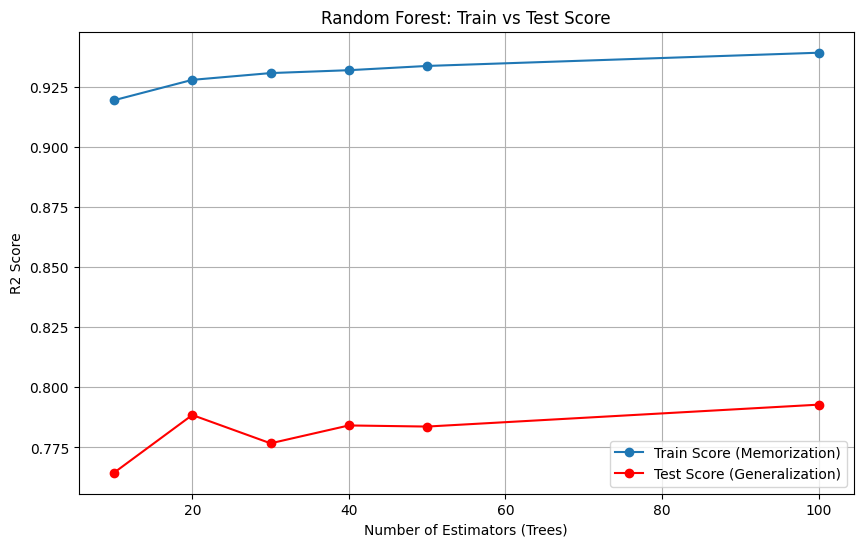

In [21]:
# 결과 저장을 위한 리스트 (나중에 그래프 그리기 위해)
train_scores = []
test_scores = []

estimators = [10, 20, 30, 40, 50, 100]

print("=== 랜덤 포레스트 성능 비교 (R2 Score) ===")

for i in estimators:
    # 모델 생성 및 학습
    model = RandomForestRegressor(
        n_estimators=i, 
        max_depth = 7, #과적합 방지 위한 깊이 제한
        min_samples_leaf = 2, #얘도
        random_state=15, 
        n_jobs=-1
        )
    model.fit(X_train, y_train)
    
    # 1. 학습 데이터 점수 (얼마나 잘 외웠나?)
    train_r2 = model.score(X_train, y_train)
    
    # 2. 테스트 데이터 점수 (얼마나 잘 맞추나?)
    test_r2 = model.score(X_test, y_test)
    
    # 리스트에 저장
    train_scores.append(train_r2)
    test_scores.append(test_r2)
    
    print(f'Trees: {i:3d} | Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}')



# n_estimators 변화에 따른 점수 차이 시각화
plt.figure(figsize=(10, 6))
plt.plot(estimators, train_scores, marker='o', label='Train Score (Memorization)')
plt.plot(estimators, test_scores, marker='o', label='Test Score (Generalization)', color='red')
plt.xlabel('Number of Estimators (Trees)')
plt.ylabel('R2 Score')
plt.title('Random Forest: Train vs Test Score')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# R2 Score (설명력)
r2 = r2_score(y_test, pred)

# RMSE (큰 에러에 민감)
rmse = np.sqrt(mean_squared_error(y_test, pred))

# MAE (평균 에러)
mae = mean_absolute_error(y_test, pred)

print("=== 모델 최종 성능 평가 ===")
print(f"1. R2 Score (설명력):  {r2:.4f}") #1에 가까울수록 좋음
print(f"2. RMSE (평균오차):    {rmse:.4f}") #0에 가까울수록 좋음
print(f"3. MAE (절대오차):     {mae:.4f}")
print("-" * 30)
print(f"참고: y_test(정답)의 평균값은 {y_test.mean():.4f} 입니다.")
print(f"해석: 평균 {y_test.mean():.1f} 정도의 수치를 예측하는데, 약 ±{mae:.1f} 정도 틀립니다.")

=== 모델 최종 성능 평가 ===
1. R2 Score (설명력):  0.7884 (1에 가까울수록 좋음)
2. RMSE (평균오차):    2.8264 (0에 가까울수록 좋음)
3. MAE (절대오차):     2.0283
------------------------------
참고: y_test(정답)의 평균값은 5.0191 입니다.
해석: 평균 5.0 정도의 수치를 예측하는데, 약 ±2.0 정도 틀립니다.
